# IMPORTS

In [43]:
import pandas as pd
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




# PATH SETTINGS

In [44]:
TRAINING_FOLDERS = {
    0: r"C:\FinalDataset\dataset\dataset\1 star",
    1: r"C:\FinalDataset\dataset\dataset\2 star",
    2: r"C:\FinalDataset\dataset\dataset\3 star",
    3: r"C:\FinalDataset\dataset\dataset\4 star",
    4: r"C:\FinalDataset\dataset\dataset\5 star"
}

MODEL_SAVE_LSTM = r"C:\Anti\lstm_model23.h5"
SCALER_SAVE = r"C:\Anti\scaler23.pkl"
TEST_FILE = r"C:\Sample1data\1 star\Daniyal_aggresive2.csv"

# SETTINGS

In [45]:
WINDOW_SIZE = 120
STEP_SIZE = 20

FEATURES = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z','acc_mag','gyro_mag']
LABEL_NAMES = ['Aggressive', 'Rush', 'Moderate', 'Smooth', 'Safe']

# LOAD + WINDOW DATA

In [46]:
print("\n[1] Loading Dataset...")

X, y = [], []

for label, folder in TRAINING_FOLDERS.items():
    print(f"Processing: {folder}")

    csv_files = glob.glob(os.path.join(folder, "*.csv"))

    for file in csv_files:
        try:
            df = pd.read_csv(file)

            # Fix column names
            if 'X_Acc' in df.columns:
                df.rename(columns={
                    'X_Acc': 'acc_x', 'Y_Acc': 'acc_y', 'Z_Acc': 'acc_z',
                    'X_Gyro': 'gyro_x', 'Y_Gyro': 'gyro_y', 'Z_Gyro': 'gyro_z'
                }, inplace=True)

            # Safety check
            if not all(col in df.columns for col in ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']):
                print(f"Skipping {file}")
                continue

            #  Feature Engineering
            df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
            df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

            values = df[FEATURES].values.astype(np.float32)

            for i in range(0, len(values) - WINDOW_SIZE, STEP_SIZE):
                X.append(values[i:i + WINDOW_SIZE])
                y.append(label)

        except Exception as e:
            print(f"Error in {file}: {e}")

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)


[1] Loading Dataset...
Processing: C:\FinalDataset\dataset\dataset\1 star
Processing: C:\FinalDataset\dataset\dataset\2 star
Processing: C:\FinalDataset\dataset\dataset\3 star
Processing: C:\FinalDataset\dataset\dataset\4 star
Skipping C:\FinalDataset\dataset\dataset\4 star\Lokesh_safe1.csv
Processing: C:\FinalDataset\dataset\dataset\5 star
Dataset Shape: (145711, 120, 8)


# SPLIT

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("\nClass Weights:", class_weights)




Class Weights: {np.int64(0): np.float64(1.0233342112193837), np.int64(1): np.float64(0.9180389840519787), np.int64(2): np.float64(0.8647798508846767), np.int64(3): np.float64(0.9751380291115944), np.int64(4): np.float64(1.330381191508788)}


# SCALING

In [48]:
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, len(FEATURES)))

X_train = scaler.transform(X_train.reshape(-1, len(FEATURES))).reshape(len(X_train), WINDOW_SIZE, len(FEATURES))
X_test = scaler.transform(X_test.reshape(-1, len(FEATURES))).reshape(len(X_test), WINDOW_SIZE, len(FEATURES))

with open(SCALER_SAVE, 'wb') as f:  
    pickle.dump(scaler, f)

# MODEL BUILDING 

In [50]:
# ============================================================
# MODEL BUILDING (CNN + BIDIRECTIONAL LSTM)
# ============================================================
from tensorflow.keras.layers import Conv1D, MaxPooling1D

lstm_model= Sequential([
    # CNN PART (detects local patterns)
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(FEATURES))),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    # LSTM PART (sequence learning)
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    
    # DENSE PART
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 118, 64)        │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 116, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 58, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 58, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 58, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 58, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,437 (1.47 MB)

 Trainable params: 386,437 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

# TRAINING

In [51]:
print("\n[2] Training LSTM File...")
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

y_train_final = to_categorical(y_train_final, 5)
y_val = to_categorical(y_val, 5)
y_test_cat = to_categorical(y_test, 5)

history = lstm_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights
)

lstm_model.save(MODEL_SAVE_LSTM)

print("Training Complete!")





[2] Training LSTM File...
Epoch 1/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 143s 90ms/step - accuracy: 0.6144 - loss: 0.8988 - val_accuracy: 0.6935 - val_loss: 0.7342
Epoch 2/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 230s 149ms/step - accuracy: 0.7390 - loss: 0.6039 - val_accuracy: 0.7614 - val_loss: 0.6112
Epoch 3/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 171s 110ms/step - accuracy: 0.7738 - loss: 0.5291 - val_accuracy: 0.8093 - val_loss: 0.4452
Epoch 4/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 140s 90ms/step - accuracy: 0.7971 - loss: 0.4725 - val_accuracy: 0.8358 - val_loss: 0.3888
Epoch 5/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 144s 93ms/step - accuracy: 0.8127 - loss: 0.4320 - val_accuracy: 0.8206 - val_loss: 0.4270
Epoch 6/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 145s 94ms/step - accuracy: 0.8167 - loss: 0.4230 - val_accuracy: 0.8334 - val_loss: 0.3857
Epoch 7/20
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 145s 93ms/step - accuracy: 0.8265 - loss: 0.3988 - val_accuracy: 0.8438 - val_loss: 0.3414
Epoch 8/20
1549/1549 ━━━━━━━━━━━━━━━━━━━

Training Complete!


# EVALUATION

In [52]:
print("\nLSTM Classification Report:\n")
lstm_probs = lstm_model.predict(X_test)
lstm_pred = np.argmax(lstm_probs, axis=1)
print(classification_report(y_test, lstm_pred, target_names=LABEL_NAMES))


LSTM Classification Report:

911/911 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step
              precision    recall  f1-score   support

  Aggressive       0.85      0.89      0.87      5696
        Rush       0.97      0.94      0.95      6349
    Moderate       0.97      0.88      0.92      6740
      Smooth       0.74      0.93      0.82      5977
        Safe       0.92      0.71      0.80      4381

    accuracy                           0.88     29143
   macro avg       0.89      0.87      0.87     29143
weighted avg       0.89      0.88      0.88     29143



Accuracy

In [53]:
# ================= ACCURACY =================
lstm_acc = accuracy_score(y_test, lstm_pred)
print("\nLSTM Accuracy:", lstm_acc)


LSTM Accuracy: 0.8789760834505713


# CONFUSION MATRIX

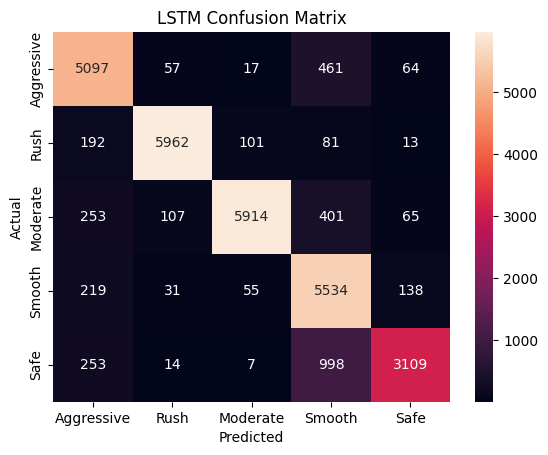

In [54]:
cm_lstm = confusion_matrix(y_test, lstm_pred)

plt.figure()
sns.heatmap(cm_lstm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

# DRIVING SCORE FUNCTION

In [55]:
def calculate_driving_score(predictions):
    avg_probs = np.mean(predictions, axis=0)
    weights = np.array([20, 40, 60, 80, 100])
    return round(np.dot(avg_probs, weights), 2)

# TEST FUNCTION

In [57]:
def test_on_file(csv_path):

    df = pd.read_csv(csv_path)

    if 'X_Acc' in df.columns:
        df.rename(columns={
            'X_Acc': 'acc_x', 'Y_Acc': 'acc_y', 'Z_Acc': 'acc_z',
            'X_Gyro': 'gyro_x', 'Y_Gyro': 'gyro_y', 'Z_Gyro': 'gyro_z'
        }, inplace=True)

    # Feature Engineering
    df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

    
    data = df[FEATURES].values

    windows = [
        data[i:i + WINDOW_SIZE]
        for i in range(0, len(data) - WINDOW_SIZE, STEP_SIZE)
    ]

    if len(windows) == 0:
        print("Not enough data!")
        return

    X_val = np.array(windows)
    X_val = scaler.transform(X_val.reshape(-1, len(FEATURES))).reshape(len(X_val), WINDOW_SIZE, len(FEATURES))

   
    preds_lstm = lstm_model.predict(X_val, verbose=0) # verbose=0 hides the progress bar for cleaner output
    score_lstm = calculate_driving_score(preds_lstm)
    avg_probs_lstm = np.mean(preds_lstm, axis=0)
    pred_class_lstm = np.argmax(avg_probs_lstm)
    print("\n" + "="*40)
    print(" LSTM MODEL PREDICTION")
    print("="*40)
    print(f"Driving Score: {score_lstm}/100")
    print(f"Driving Style: {LABEL_NAMES[pred_class_lstm]}")

# RUN TEST

In [58]:
print(f"Test File Name {TEST_FILE}")
if os.path.exists(TEST_FILE):
    test_on_file(TEST_FILE)
else:
    print("Test file not found!")

Test File Name C:\Sample1data\1 star\Daniyal_aggresive2.csv

 LSTM MODEL PREDICTION
Driving Score: 24.89/100
Driving Style: Aggressive
